## 学习孟德尔随机化分析
孟德尔随机化分析（Mendelian Randomization, MR） 是一种利用遗传变异（主要是单核苷酸多态性，SNP）作为工具变量（Instrumental Variable, IV），来推断某个暴露因素（exposure）与结局（outcome，如疾病）之间因果关系的流行病学和统计学方法。它被形象地称为“自然界的随机对照试验（RCT）”或“最接近因果推断的观察性研究方法”。

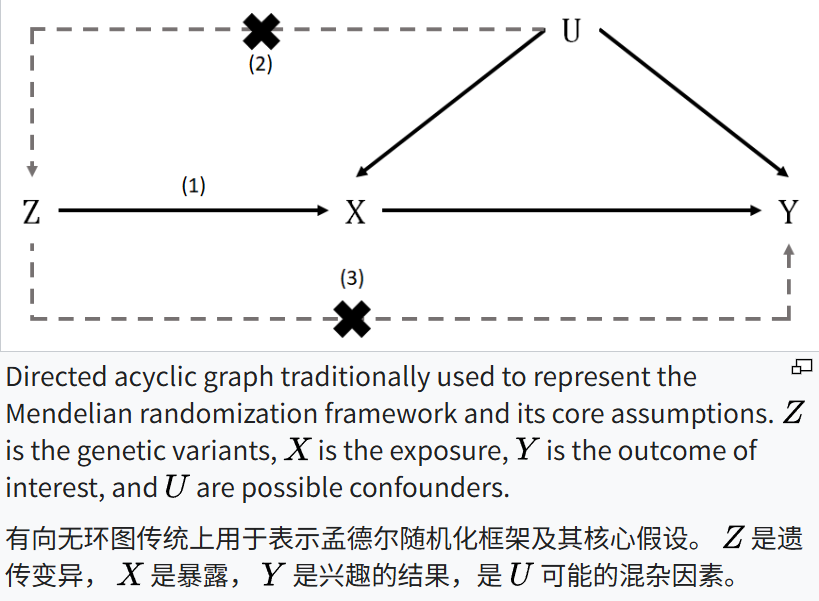

## 为什么需要孟德尔随机化？
- 传统观察性研究（如队列研究、病例对照研究）常面临两大难题：混杂偏倚（Confounding）：暴露与结局可能受年龄、吸烟、生活方式、 socioeconomic status 等未知或未测量的混杂因素影响。
- 反向因果（Reverse Causation）：可能是结局导致了暴露（如疾病导致生活方式改变），而不是暴露导致结局。

随机对照试验（RCT）能很好解决这些问题，但很多暴露（如饮酒、BMI、血压水平）无法或不道德进行随机干预。孟德尔随机化正是为了解决这些问题而设计的“虚拟RCT”。



## 核心原理
孟德尔随机化基于孟德尔遗传定律（尤其是第二定律：独立分配/自由组合规律）：
- 在受精时，亲代的等位基因随机分配给子代，类似于RCT中的随机分组。
- 遗传变异（SNP）在出生前就固定，不受后天环境、行为或疾病影响。
- 因此，SNP 可以作为“工具变量”来模拟对暴露的随机分配，从而推断暴露对结局的因果效应。

简单比喻：如果你想知道“高血压是否导致心脏病”，传统研究可能受吸烟、饮食等混杂影响。但如果你找到一些只影响血压（不直接影响心脏病或其他混杂）的基因变异，用这些基因来比较“遗传上血压高” vs “遗传上血压低”的人群的心脏病风险，就能更干净地推断因果。



## 孟德尔随机化的三个核心假设（必须满足，否则结果不可靠）
- **关联性假设（Relevance Assumption）**：工具变量（SNP）必须与暴露因素强相关（通常用GWAS中 p < 5×10⁻⁸ 的SNP，F统计量 > 10 避免弱工具变量偏倚）。
- **独立性假设（Independence Assumption）**：工具变量与任何影响结局的混杂因素无关（遗传随机分配使得SNP通常独立于环境混杂）。
- **排他性假设 / 无水平多效性假设（Exclusion Restriction / No Horizontal Pleiotropy）**：工具变量只能通过暴露影响结局，不能通过其他独立路径直接影响结局（这是最难验证的假设，常需敏感性分析检查）。

如果违反这些假设，会产生偏倚（如水平多效性：SNP 通过其他途径影响结局）。



## 常见类型
- 单样本MR：暴露、工具变量和结局数据来自同一个样本（较少用，因样本重叠问题）。
- 两样本MR（Two-Sample MR，最常用）：暴露的GWAS数据和结局的GWAS数据来自两个独立的大样本（如IEU OpenGWAS、FinnGen数据库），统计效能高、易操作。
- 两步MR / 中介MR（Two-Step MR / Mediation MR）：用于探究机制，例如“卒中 → 糖尿病并发症 → 心律失常”，第一步算暴露对中介的效应，第二步算中介对结局的效应，再计算间接效应比例。
- 多变量MR（MVMR）：同时纳入多个暴露，估计独立效应。
- 跨代孟德尔随机化（Intergenerational Mendelian Randomization，或称 Multigenerational / Cross-generational MR）是孟德尔随机化（MR）方法的一个重要扩展分支。它专门用于研究亲代（父母）暴露因素对子代（后代）健康结局的因果影响，同时尝试分离遗传效应与环境效应（尤其是宫内环境、育儿环境等非遗传传递）。跨代MR利用亲子三联体（mother-father-offspring trios）或亲代-子代GWAS数据，通过巧妙的遗传设计来“剥离”这两种效应，从而更干净地推断父母暴露是否因果影响子代。

## 主要分析方法（从简单到稳健）
- 主分析：Inverse Variance Weighted (IVW) —— 假设所有SNP都是有效工具变量时的加权平均。
- 敏感性分析（必须做，用于验证稳健性）：
    - MR-Egger：检测并校正定向多效性（截距检验）。
    - Weighted Median：允许最多50%的SNP无效时仍稳健。
    - Weighted Mode、Simple Mode。
    - MR-PRESSO：检测并移除异常值（outliers）。
    - Leave-one-out（逐一剔除SNP看结果是否稳定）。
    - 异质性检验（Cochran’s Q）。

常用R包：TwoSampleMR（最流行）、MRPRESSO 等，可直接从公开GWAS汇总统计数据（summary statistics）进行分析，无需原始个体数据。



## 优点

    能较好避免传统观察性研究的混杂和反向因果。
    遗传变异测量准确、稳定、终身固定。
    成本低、可利用海量公开GWAS数据（样本量常达数十万至百万）。
    因果方向明确（遗传在前）。

## 局限性与注意事项

    依赖三个假设，实际中水平多效性常见，需要严格敏感性分析。
    弱工具变量偏倚（F<10 时效应被低估）。
    人群特异性（多数数据为欧洲血统，结果泛化到其他人群需谨慎）。
    不能完全替代RCT，只能提供因果证据支持。
    生物学解释需谨慎（MR给出的是“终身遗传效应”，可能与短期干预不同）。
    样本重叠、胜利者诅咒（winner’s curse）等潜在问题。

## **实战**：两样本孟德尔随机化分析
参考：https://www.yuque.com/tully-sci/consensus/wts8foqt1c2r6cqf

## 本研究研究数据：
- 暴露因素是体重指数 (body mass index, BMI)
- 结局是冠心病 (Coronary heart disease)
  
## 下载数据集
可在[IEU OpenGWAS](https://opengwas.io/datasets/)进行搜索下载
```bash
## 冠心病数据集：ieu-a-7
wget -c https://ieup4.objectstorage.uk-london-1.oci.customer-oci.com/p/9jtdGvO_R4BpWN_xPE-3_cqGGo0tz-VsW3Psn6GfdYTgHNlHSEiW_oktIvU7B3ua/n/ieup4/b/igd/o/ieu-a-7/ieu-a-7.vcf.gz & 
wget -c https://ieup4.objectstorage.uk-london-1.oci.customer-oci.com/p/YJAAnTK04mTKTrwERj6vCdWuoeq-_KWF9xLNsZbSLQ8u4ODQXClrx9dl5gLyhS6B/n/ieup4/b/igd/o/ieu-a-7/ieu-a-7.vcf.gz.tbi & 

## 体重指数数据集：ieu-a-2
wget -c https://ieup4.objectstorage.uk-london-1.oci.customer-oci.com/p/ZmY2cEe-rWnkLt46VG4jTgSOvIHt0IwqyojodOwtnC8DNXCgWY9yplpxwrKWa_Qg/n/ieup4/b/igd/o/ieu-a-2/ieu-a-2.vcf.gz & 
wget -c https://ieup4.objectstorage.uk-london-1.oci.customer-oci.com/p/NzfOt5vmJfcvRN3Wnk2EJ7kSbQ6DAwDS_lp1rvEc8srailW2TR-x2EMTpBoHB76_/n/ieup4/b/igd/o/ieu-a-2/ieu-a-2.vcf.gz.tbi & 

wait
```

### 安装R包

In [5]:
install_if_not_installed <- function(pkg, install_function = install.packages) {
  if (!requireNamespace(pkg, quietly = TRUE)) {
    if (identical(install_function, install.packages)) {
      install.packages(pkg)
    } else {
      install_function(pkg)
    }
  }
}

pkgs <- c("VariantAnnotation", "gwasglue", "dplyr", "tidyr", "CMplot")

install_if_not_installed("devtools")
# install_if_not_installed("gwasglue", devtools::install_github("mrcieu/gwasglue", force = TRUE))
install_if_not_installed("BiocManager")
install_if_not_installed("VariantAnnotation", BiocManager::install)
install_if_not_installed("dplyr")
install_if_not_installed("tidyr")
install_if_not_installed("CMplot")

lapply(pkgs, function(pkg) { suppressMessages(library(pkg, character.only = TRUE, quietly = TRUE)) })

Updating HTML index of packages in '.Library'

Making 'packages.html' ...
 done



ERROR: Error in library(pkg, character.only = TRUE, quietly = TRUE): there is no package called ‘gwasglue’


## 筛选工具变量SN
- 筛选强关联的 SNP (P<5×10-8)
- 去除连锁不平衡效应 (在 10000 kb 范围内 r2 大于 0.001 的 SNP)

## 获取OpenGWAS API token
- 1. 打开https://api.opengwas.io/profile/，用用github账号登录
- 2. 复制token
- 3. 设置 GitHub token; 在R中输入：gitcreds::gitcreds_set()
- 4. 然后粘贴token

In [ ]:
 install.packages(
  'gwasglue',
  repos = c(
    'https://mrcieu.r-universe.dev',
    'https://cloud.r-project.org'
  )
)


In [25]:
library(VariantAnnotation)
library(TwoSampleMR)
library("devtools")
library(gwasglue)
# 查看函数是否存在
# exists("gwasvcf_to_TwoSampleMR")
library(CMplot)
library(tidyr)
library(dplyr)

In [22]:

input_file <- '../data/20260327/ieu-a-2.vcf.gz' # BMI dataset
threshold <- 5e-08
output_fmt <- "png"

# # ---读取数据并转换为 TwoSampleMR 格式
vcf_data <- readVcf(input_file)
two_sample_MR_data <- gwasvcf_to_TwoSampleMR(vcf = vcf_data, type = "exposure")

# ---滤去关联性弱的 SNP 并输出到文件
out_table <- subset(two_sample_MR_data, pval.exposure < threshold)

In [37]:
write.csv(out_table, file = "exposure.pvalue.csv", row.names = FALSE)

In [28]:
# ---曼哈顿图数据准备
# SNP：SNP ID
# CHR：染色体名称
# BP：基因位点（Base Pair）
# pvalue：P值
two_sample_MR_data <- two_sample_MR_data[, c("SNP", "chr.exposure", "pos.exposure", "pval.exposure")]
colnames(two_sample_MR_data) <- c("SNP", "CHR", "BP", "pvalue")

# ---绘制输出（“m”线性曼哈顿图，“c”环形曼哈顿图）
CMplot(two_sample_MR_data, plot.type = "m",
       LOG10 = TRUE, threshold = threshold, threshold.lwd = 3, threshold.lty = 1, signal.cex = 0.2,
       chr.den.col = NULL, cex = 0.2, bin.size = 1e5, ylim = c(0, 50), width = 15, height = 9,
       file.output = TRUE, file = output_fmt, verbose = TRUE)

 Rectangular Manhattan plotting pvalue.
 Plots are stored in: /mnt/d/01_study/0001.note_sharing/notebook 


In [32]:
# 1. 先设置白色背景（防止黑背景）
options(repr.plot.bg = "white")   
par(bg = "white")


In [35]:
CMplot(two_sample_MR_data, plot.type = "m",
       LOG10 = TRUE, threshold = threshold, threshold.lwd = 3, threshold.lty = 1, signal.cex = 0.2,
       chr.den.col = NULL, cex = 0.2, bin.size = 1e5, ylim = c(0, 50), width = 15, height = 9,
       )#file.output = TRUE, file = output_fmt,verbose = TRUE

 Rectangular Manhattan plotting pvalue.
 Plots are stored in: /mnt/d/01_study/0001.note_sharing/notebook 


In [36]:
CMplot(two_sample_MR_data, plot.type = "c",
       LOG10 = TRUE, threshold = threshold, threshold.lwd = 3, threshold.lty = 1, signal.cex = 0.2,
       chr.den.col = NULL, cex = 0.2, bin.size = 1e5, ylim = c(0, 100), width = 7, height = 7,
       verbose = TRUE)#file.output = TRUE, file = output_fmt, 

 Circular Manhattan plotting pvalue.
 Plots are stored in: /mnt/d/01_study/0001.note_sharing/notebook 


## 去除连锁不平衡效应

In [41]:
exposure_csv_file <- "exposure.pvalue.csv"

# ---读取相关性分析结果文件
exposure_data <- read_exposure_data(
  filename = exposure_csv_file,
  sep = ",",
  snp_col = "SNP",
  beta_col = "beta.exposure",
  se_col = "se.exposure",
  effect_allele_col = "effect_allele.exposure",
  other_allele_col = "other_allele.exposure",
  eaf_col = "eaf.exposure",
  samplesize_col = "samplesize.exposure",
  clump = FALSE)

# ---去除连锁不平衡的 SNP（在 10000 kb 范围内 r2 大于 0.001 的 SNP）并输出到文件
exposure_dat_clumped <- clump_data(exposure_data, clump_kb = 10000, clump_r2 = 0.001,)
# write.csv(exposure_dat_clumped, file = "exposure.LD.csv", row.names = FALSE)

No phenotype name specified, defaulting to 'exposure'.

Inferring p-values

Please look at vignettes for options on running this locally if you need to run many instances of this command.

Clumping 6XDZcf, 2041 variants, using EUR population reference



ERROR: Error in get_query_content(.): 
Status code from OpenGWAS API: 401

Message: ERROR - Go to https://api.opengwas.io/ - From 1st May 2024 you must provide a token (JWT) alongside most of your requests. Read more at https://api.opengwas.io/ and also check for the latest version at https://mrcieu.github.io/ieugwasr/
